In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from numpy import cos,pi,sqrt
from astropy.table import Table
from astropy.table import unique
import os
import ctadata
from astropy.io import ascii

In [60]:
src_name="M87" #http://odahub.io/ontology#AstrophysicalObject
RA=83.628700  # http://odahub.io/ontology#PointOfInterestRA
DEC = 22.014700 # http://odahub.io/ontology#PointOfInterestDEC
T1='2020-09-09T13:16:00.0'# http://odahub.io/ontology#StartTime
T2='2026-01-10T13:16:00.0' # http://odahub.io/ontology#EndTime

Radius=5. # http://odahub.io/ontology#AngleDegrees


In [61]:
Name=src_name
gheff='gheff0.7'
coords_obj=SkyCoord.from_name(Name)
ra_obj=coords_obj.icrs.ra.deg
dec_obj=coords_obj.icrs.dec.deg
ra_obj,dec_obj
cdec=cos(dec_obj*pi/180.)
ra_obj,dec_obj


(187.70593077, 12.39112325)

In [62]:
run_catalog=ascii.read('LST_source_catalog.ecsv')
good_runs=ascii.read('run_catalog_dark_nights300.dat')


In [63]:
ra_pnts=good_runs['RA_PNT']
dec_pnts=good_runs['DEC_PNT']
coords_pnts=SkyCoord(ra_pnts,dec_pnts,unit='degree')
fnames=good_runs['FILENAME']

10

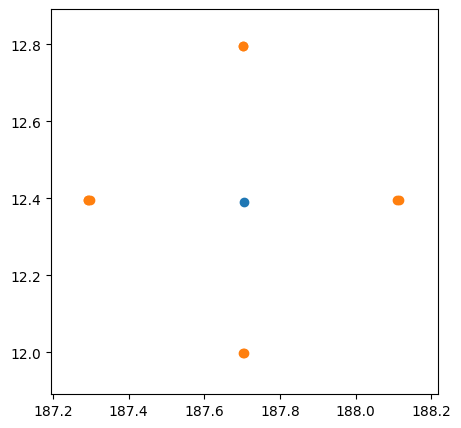

In [64]:
seps=coords_pnts.separation(coords_obj).deg
m=(seps<Radius)
selected_runs=good_runs[m]

plt.figure(figsize=(5,5))
plt.scatter([ra_obj],[dec_obj])
plt.scatter([selected_runs['RA_PNT']],[selected_runs['DEC_PNT']])
plt.xlim(ra_obj-0.5/cdec,ra_obj+0.5/cdec)
plt.ylim(dec_obj-0.5,dec_obj+0.5)
len(selected_runs)

In [56]:
Ebins=np.logspace(-1,2,16)
Emins=Ebins[:-1]
Emaxs=Ebins[1:]
Emeans=sqrt(Emins*Emaxs)
dE=Emaxs-Emins
Nebins=len(Emeans)


In [57]:
pixsize=0.1
imsize=3
npix=int(imsize/pixsize)*2+1
rabins=np.linspace(ra_obj-imsize/cdec,ra_obj+imsize/cdec,npix+1)
decbins=np.linspace(dec_obj-imsize,dec_obj+imsize,npix+1)
images=np.zeros((Nebins,npix,npix))

In [58]:
counter=0
texpos=np.array([])
for f in selected_runs['FILENAME']:
    counter+=1
    ctadata.fetch_and_save_file_or_dir(f)
    fname=f.split('/')[-1]
    hdul=fits.open(fname)
    header=hdul['EVENTS'].header
    texpos=np.concatenate((texpos,[header['LIVETIME']]))
    print(counter,fname,'exposure:',sum(texpos)/3600.)
    events=hdul['EVENTS'].data        
    ras=events['RA']
    decs=events['DEC']    
    for i in range(len(Emeans)):
        m=(events['ENERGY']>Emins[i])*(events['ENERGY']<Emaxs[i])
        h=np.histogram2d(ras[m],decs[m],bins=[rabins,decbins])
        images[i]+=h[0]

    os.remove(fname)


1 dl3_LST-1.Run04207.fits exposure: 0.307049669764031
2 dl3_LST-1.Run04335.fits exposure: 0.5457620559708571
3 dl3_LST-1.Run04336.fits exposure: 0.7827936631725111
4 dl3_LST-1.Run04343.fits exposure: 1.0976848270537756
5 dl3_LST-1.Run04344.fits exposure: 1.2158761201187094
6 dl3_LST-1.Run04363.fits exposure: 1.5009826801686985
7 dl3_LST-1.Run04364.fits exposure: 1.8242797101615316
8 dl3_LST-1.Run04365.fits exposure: 1.918217012952935
9 dl3_LST-1.Run04366.fits exposure: 2.2492119922157894
10 dl3_LST-1.Run04367.fits exposure: 2.5783766766014136
11 dl3_LST-1.Run04368.fits exposure: 2.874745225835426
12 dl3_LST-1.Run04369.fits exposure: 3.1126549940133277
13 dl3_LST-1.Run04370.fits exposure: 3.172714522507536


0.3981071705534973

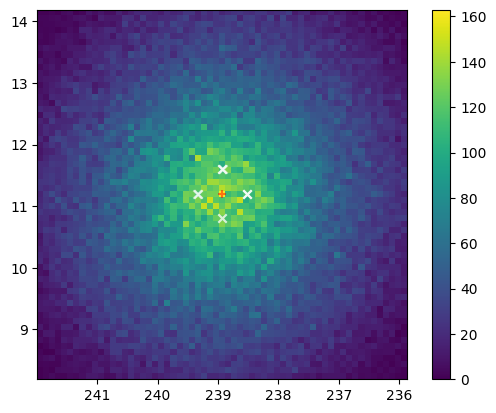

In [59]:
ind=3
plt.imshow(np.sum(images[ind:],axis=0),extent=[rabins[-1],rabins[0],decbins[0],decbins[-1]],aspect=1/cdec)
plt.colorbar()
plt.scatter([ra_obj],[dec_obj],color='red',marker='+',alpha=0.5)
plt.scatter([selected_runs['RA_PNT']],[selected_runs['DEC_PNT']],color='white',alpha=0.5,marker='x')
Emins[ind]